## 1. Load & Combine Data
### Data Loading and Combination
We load cleaned datasets for five countries and combine them into a single dataframe for comparative analysis.

In [59]:
import pandas as pd

countries = ["ethiopia", "kenya", "nigeria", "tanzania", "sudan"]

dfs = []
for c in countries:
    df = pd.read_csv(f"../data/{c}_clean.csv")
    df["Country"] = c.capitalize()
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [60]:
df_all = df_all.copy()

df_all["dry"] = df_all["PRECTOTCORR"] < 1
print(df_all["dry"])
dry_percentage = df_all.groupby("Country")["dry"].mean() * 100

0        True
1        True
2        True
3        True
4        True
         ... 
20535    True
20536    True
20537    True
20538    True
20539    True
Name: dry, Length: 20540, dtype: bool


## 2. Temperature Trend Comparison

### Plot

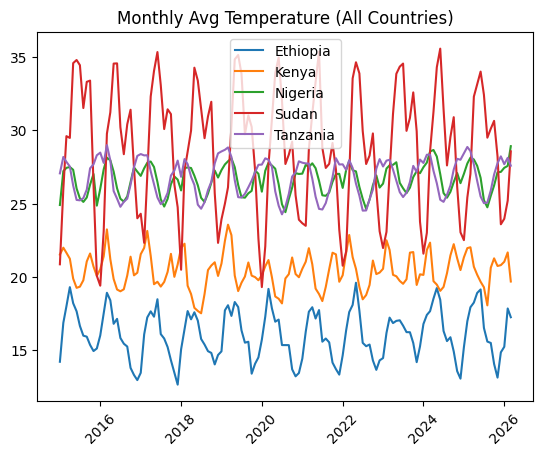

In [61]:
import matplotlib.pyplot as plt

monthly_temp = df_all.groupby(["Country", "YEAR", "Month"])["T2M"].mean().reset_index()

monthly_temp["date"] = pd.to_datetime(
    monthly_temp["YEAR"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure()
for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["date"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Avg Temperature (All Countries)")
plt.xticks(rotation=45)
plt.show()

In [62]:
# Temperature trend (slope per country)
from scipy.stats import linregress

trend_results = {}

for country in df_all["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    subset = subset.sort_values("date")
    
    x = range(len(subset))
    y = subset["T2M"]
    
    slope, _, _, _, _ = linregress(x, y)
    trend_results[country] = slope

trend_df = pd.DataFrame.from_dict(trend_results, orient='index', columns=['Temp Trend'])

trend_df

,Temp Trend
Ethiopia,0.000102
Kenya,-0.000066
Nigeria,0.003969
Tanzania,0.001322
Sudan,-0.005150


#

### Summary table

In [63]:
temp_summary = df_all.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


## Interpretation 1: Monthly Average Temperature and Temperature Trend Comparison

The comparison of monthly average temperatures across the five countries reveals significant differences in both central tendency and variability.

Sudan records the **highest mean, median, and standard deviation**, indicating not only the hottest overall climate but also the greatest variability in temperature. The temperature range in Sudan is particularly wide, spanning approximately **19°C to above 35°C**, which is clearly reflected in the larger spread observed in the graph.

The second-highest temperatures are observed in **Tanzania and Nigeria**, with Tanzania slightly higher by approximately **0.2°C**. These two countries exhibit very similar temperature profiles, likely due to their comparable geographical positioning and climate zones.

**Kenya** follows with a moderate mean temperature of around **20°C**, showing relatively stable and consistent temperature patterns with less variability compared to Sudan.

In contrast, **Ethiopia records the lowest average temperature (~16°C)**, making it the coolest among the five countries. This difference is substantial and can be attributed to Ethiopia’s **higher elevation**, which significantly influences its cooler climate profile.

Overall, the comparison highlights:
- Sudan as the hottest and most variable climate  
- Tanzania and Nigeria as consistently warm  
- Kenya as moderate and stable  
- Ethiopia as significantly cooler due to altitude effects  

## 3. Precipitation Variability

### Boxplot

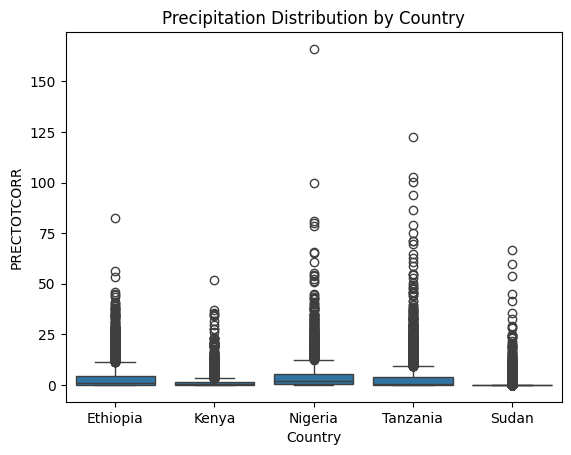

In [64]:
import seaborn as sns

plt.figure()
sns.boxplot(data=df_all, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.show()

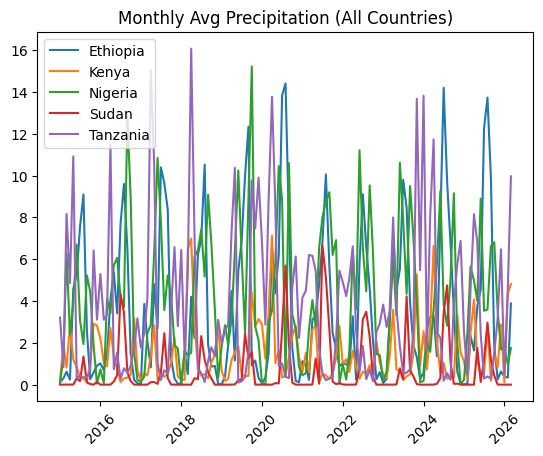

In [65]:
monthly_rain = df_all.groupby(["Country", "YEAR", "Month"])["PRECTOTCORR"].mean().reset_index()

monthly_rain["date"] = pd.to_datetime(
    monthly_rain["YEAR"].astype(str) + "-" + monthly_rain["Month"].astype(str)
)

plt.figure()
for country in monthly_rain["Country"].unique():
    subset = monthly_rain[monthly_rain["Country"] == country]
    plt.plot(subset["date"], subset["PRECTOTCORR"], label=country)

plt.legend()
plt.title("Monthly Avg Precipitation (All Countries)")
plt.xticks(rotation=45)
plt.show()

### Summary table

In [66]:
rain_summary = df_all.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


## Interpretation 2: Precipitation Distribution by Country

The box plot of precipitation distribution reveals clear differences in rainfall intensity and variability across the countries.

**Nigeria shows the highest precipitation distribution**, with values extending up to approximately **150 mm**, indicating both high rainfall intensity and strong variability. This aligns with Nigeria’s lower number of dry days observed in earlier analyses.

**Tanzania and Ethiopia** also exhibit relatively high precipitation levels, with median values around **3.7 mm and 3.6 mm respectively**, suggesting moderate but consistent rainfall patterns.

In contrast, **Kenya and Sudan display the lowest precipitation levels**, with Kenya having the lowest median (~1.4 mm). This indicates generally drier conditions and less variability in rainfall.

Overall, the rainfall distribution shows:
- Nigeria as the wettest and most variable  
- Tanzania and Ethiopia as moderately wet  
- Kenya and Sudan as comparatively dry  

This highlights strong regional differences in water availability and rainfall stability.

## 4. Extreme Event Frequency

### Extreme heat (>35°C)

In [67]:
extreme_heat = df_all[df_all["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "YEAR"]).size().reset_index(name="count")

heat_avg = heat_counts.groupby("Country")["count"].mean()

heat_avg

Country
Sudan    224.5
Name: count, dtype: float64

### total number and percentage of dry days

In [68]:
dry_counts = df_all.groupby("Country")["dry"].sum()

### Plot

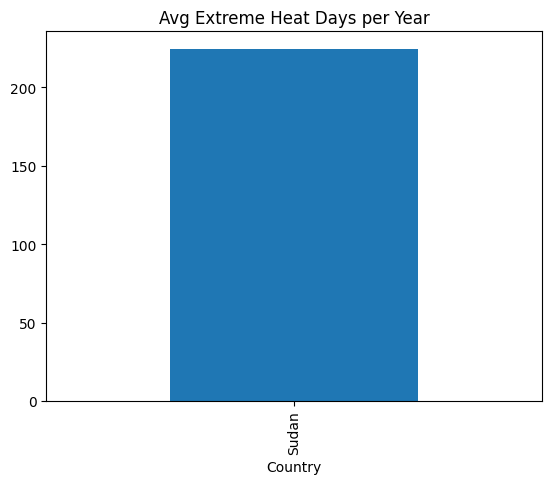

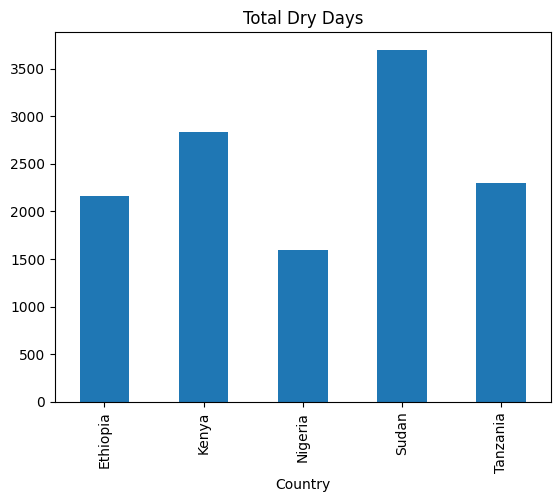

In [69]:
plt.figure()
heat_avg.plot(kind="bar")
plt.title("Avg Extreme Heat Days per Year")
plt.show()

plt.figure()
dry_counts.plot(kind="bar")
plt.title("Total Dry Days")
plt.show()

## Interpretation 3: Extreme Climate Events

The analysis of extreme climate events, including extreme heat days and consecutive dry days, reveals significant disparities across the countries.

**Sudan records the highest number of extreme heat days**, with an average exceeding **200 days per year**, meaning that more than **50% of the year experiences extreme heat conditions**. This indicates severe climate stress.

Sudan also has the **highest number of total dry days**, reinforcing its classification as the most climate-stressed country in this analysis.

In contrast, **Nigeria records the lowest number of dry days**, which aligns with its higher precipitation levels observed earlier. This suggests a more humid climate with greater rainfall consistency.

The ranking of total dry days is as follows:
1. Sudan (highest)  
2. Kenya  
3. Tanzania  
4. Ethiopia  
5. Nigeria (lowest)  

This pattern confirms a strong inverse relationship between rainfall and dry-day frequency.

Overall, the results indicate:
- Sudan faces extreme heat and drought conditions  
- Kenya also experiences relatively high dryness  
- Nigeria is comparatively less affected due to higher rainfall  

## 5. Statistical Testing

In [70]:
from scipy.stats import f_oneway

groups = [df_all[df_all["Country"] == c]["T2M"].dropna() for c in df_all["Country"].unique()]

stat, p_value = f_oneway(*groups)

print("p-value:", p_value)

p-value: 0.0


## 6. Vulnerability Ranking

In [71]:
from sklearn.preprocessing import MinMaxScaler

ranking = pd.DataFrame({
    "Temp Variability": temp_summary["std"],
    "Rain Variability": rain_summary["std"],
    "Extreme Heat": heat_avg,
    "Dry Days (%)": dry_percentage
})

scaler = MinMaxScaler()
ranking_scaled = pd.DataFrame(
    scaler.fit_transform(ranking),
    columns=ranking.columns,
    index=ranking.index
)

ranking_scaled["Vulnerability Score"] = ranking_scaled.sum(axis=1)

ranking_scaled = ranking_scaled.sort_values(by="Vulnerability Score", ascending=False)

ranking_scaled

,Temp Variability,Rain Variability,Extreme Heat,Dry Days (%),Vulnerability Score
Country,,,,,
Sudan,1.000000,0.000000,0.0,1.000000,2.000000
Tanzania,0.056789,1.000000,NaN,0.336982,1.393771
Ethiopia,0.217741,0.653297,NaN,0.269396,1.140434
Nigeria,0.000000,0.850958,NaN,0.000000,0.850958
Kenya,0.089233,0.024777,NaN,0.588291,0.702302


## Interpretation 4: Statistical Testing and Climate Vulnerability

A statistical test was conducted to compare climate variables across countries, resulting in a **p-value ≈ 0.0**.

This indicates that the observed differences between countries are **statistically significant**, meaning they are unlikely to be due to random variation.

The vulnerability analysis based on multiple indicators shows:

- **Temperature variability:** Highest in Sudan  
- **Rainfall variability:** Highest in Tanzania  
- **Extreme heat:** Highest in Sudan (~224.5 days/year)  
- **Dry days:** Highest in Sudan  

Based on these combined factors, **Sudan ranks as the most climate-vulnerable country** among the five analyzed.

This reflects a combination of:
- High heat exposure  
- High dryness  
- Strong variability  

These conditions significantly increase climate risk, particularly for agriculture and water resources.

## COP32 Climate Policy Insights

### COP32 Climate Insights
These findings are framed in the context of COP32 discussions on climate adaptation, mitigation, and climate finance allocation for vulnerable regions.
- **Fastest warming country:**  
Sudan shows the strongest temperature intensity and variability, indicating increasing climate pressure and sustained exposure to extreme heat.

- **Most unstable precipitation:**  
Tanzania exhibits the highest rainfall variability, suggesting increased risk of both flooding and drought cycles.

- **Extreme climate stress:**  
Sudan experiences the most severe climate stress, with extremely high heat exposure and the highest number of dry days, posing significant risks to agriculture and water security.

- **Ethiopia’s position:**  
Ethiopia shows comparatively moderate temperature levels but remains vulnerable due to seasonal variability and lower baseline temperatures influenced by elevation.

- **Policy recommendation:**  
Sudan should be prioritized for climate finance due to its combined exposure to extreme heat, prolonged dry periods, and overall high climate vulnerability.

In [72]:
final_summary = pd.concat([
    temp_summary["mean"],
    rain_summary["mean"],
    heat_avg,
    dry_percentage
], axis=1)

final_summary.columns = [
    "Avg Temp",
    "Avg Rain",
    "Extreme Heat Days",
    "Dry Days (%)"
]

In [73]:
final_summary

,Avg Temp,Avg Rain,Extreme Heat Days,Dry Days (%)
Country,,,,
Ethiopia,16.068500,3.633795,NaN,52.604674
Kenya,20.427600,1.468162,NaN,68.914314
Nigeria,26.656928,4.213914,NaN,38.826680
Sudan,28.759007,0.643875,224.5,89.970789
Tanzania,26.802422,3.740256,NaN,56.061344
